In [ ]:
%pip install deap #Se necesita importar la librería para poder usarla en google colab.
# En VSCode se instala desde terminal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 17.0 MB/s eta 0:00:00


In [2]:
import random
import matplotlib.pyplot as plt
import sys
import io

from deap import base
from deap import creator
from deap import tools


## Inicio

Primero, hay que establecer los creator, es decir, el FitnessMin y los individuos.
Se establece un FitnessMin porque se quiere que los ataques sean los mínimos y la solución óptima sería que fueran 0.
La forma de calcular el fitness sería determinando el número de parejas de reinas no atacadas.

In [3]:

creator.create("FitnessMin", base.Fitness, weights=(-1.0,)) #Se pone los weights a negativo porque se quiere minimizar
creator.create("Individual", list, fitness=creator.FitnessMin) #Los individuos son una lista porque es lo mejor para
# guardar los números, porque no será una lista binaria.


Luego, hay que definir la representación tanto de los individuos como de la población entera. Todo ello quedará guardado en el contenedor Toolbox

In [4]:
NB_QUEENS = 8 #Se define en una variable porque puede cambiar
toolbox = base.Toolbox()
# Se registra una función de generación, que se llamará a la hora de crear individuos para que se generen números
# únicos, en un rango establecido
toolbox.register("indices", random.sample, range(NB_QUEENS), NB_QUEENS)
#Ahora, hay que crear los individuos
toolbox.register("individual", tools.initIterate, creator.Individual,
    toolbox.indices)
# Luego, a partir de los individuos, se genera la población
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

Definimos ahora la función de evaluación y la registramos, junto con las operaciones propias de los algoritmos genéticos, que son selección, cruce y mutación.
A la hora de crear la función de evaluación, podemos tener en cuenta que, cuando se crearon los individuos, se hicieron de manera que cada índice es una columna; mientras que cada número representa a una fila, es decir, en la posición 1 de la lista, si está el número dos se refiere a la columna 1, fila 2. Por ello, sólo hay que centrarse en que no se ataquen en la diagonal, porque en cada fila o columna no habrá repeticiones.

In [5]:
def FuncionEvaluacion(individual):
  tamaño = len(individual)
  #Se tendrán en cuenta dos diagonales, la que sube y la que baja
  diag_1 = [0] * (2 * tamaño) #Esta es la que sube
  diag_2 = [0] * (2 * tamaño) #Esta es la que baja

  for i in range(tamaño):
      # individual[i] es la fila, i es la columna
      diag_1[i + individual[i]] += 1 #Aumenta el valor en esa posición de la diagonal
      diag_2[tamaño - 1 - i + individual[i]] += 1

  suma = 0
  #Ahora, se determinan los conflictos
  for i in range(2 * tamaño):
      if diag_1[i] > 1:
          suma += diag_1[i] - 1
      if diag_2[i] > 1:
          suma += diag_2[i] - 1
  # Tiene que devolver una tupla, porque la librería sólo acepta que la función devuelva una tupla
  return suma,


#Una vez se tiene la función de evaluación, se registra junto con las operaciones
toolbox.register("evaluate", FuncionEvaluacion)
toolbox.register("mate", tools.cxOrdered) #Operador de cruce
toolbox.register("mutate", tools.mutShuffleIndexes, indpb=2.0/NB_QUEENS) #Operador de mutación
#El operador de mutación lo que hace es intercambiar dos posiciones al azar de la lista
toolbox.register("select", tools.selTournament, tournsize=3) #El operador de selección usa la selección por torneo

Una vez está todo lo anterior definido, hay que crear la población, teniendo en cuenta factores que pueden acondicionarlo:
1. Tamaño de la población: Con pocas muestras, el algoritmo puede converger muy rápido, pero también, con muchas muestras, puede tardar mucho en procesarse
2. Diversidad inicial: Si los individuos son muy parecidos en el inicio, el algoritmo tendrá poco material para mejorar
3. Relación con el problema: Hay que definir un número acorde de población, teniendo en cuenta el problema que se va a resolver

In [6]:
def mostrar_tablero(individuo):
    n = len(individuo)
    fig, ax = plt.subplots(figsize=(6, 6))

    for fila in range(n):
        for col in range(n):
            #Este bucle se hace para dibujar el tablero
            color = "#F0D9B5" if (fila + col) % 2 == 0 else "#B58863"
            ax.add_patch(plt.Rectangle((col, fila), 1, 1, color=color))

    for col in range(n):
        #Luego está el bucle que dibujará las reinas
        fila = individuo[col]
        ax.plot(col + 0.5, fila + 0.5, 'o',
                markersize=30, color="#2C2C2C",
                markeredgecolor="white", markeredgewidth=2)
        ax.text(col + 0.5, fila + 0.5, "♛",
                ha='center', va='center',
                fontsize=18, color="white")
    # A su vez, se tienen que escribir las letras del tablero, para que se identifiquen las columnas y las filas.
    letras = [chr(ord('a') + i) for i in range(n)]
    ax.set_xticks([i + 0.5 for i in range(n)])
    ax.set_xticklabels(letras, fontsize=12)
    ax.set_yticks([i + 0.5 for i in range(n)])
    ax.set_yticklabels([str(i + 1) for i in range(n)], fontsize=12)

    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_aspect('equal')

    conflictos = individuo.fitness.values[0]
    titulo = "Se encontró la solución óptima" if conflictos == 0 else f"La mejor solución que se pudo encontrar tiene {conflictos} conflictos"
    ax.set_title(titulo, fontsize=14, pad=12)

    plt.tight_layout()
    plt.show()

He definido además, una función que mostrará el tablero final de la solución, para que se pueda comprobar de manera visual si llega a una solución acertada cuando finaliza el algoritmo. Hay que decir que, para cada vez que se ejecute el código main, puede dar soluciones diferentes.

In [ ]:
def main():
  lineas_fichero = [] # Para guardar la salida para el fichero

  pop = toolbox.population(n=100) #Se establece el número de individuos que tendrá la población
  #Luego, se evalúa a la población entera
  fitnesses = list(map(toolbox.evaluate, pop))
  for ind, fit in zip(pop, fitnesses):
      ind.fitness.values = fit
  #Definimos la probabilidad de que ocurra la mutación y de que dos individuos se crucen
  pcruce, pmutacion = 0.5, 0.2 #Para las diferentes pruebas con diferentes valores, habrá que ir cambiándolos
  g = 0 #Es el contador de generaciones

  lista_mejor = []
  lista_media = []

  #Se hace el bucle while, que acabará cuando el mínimo sea encontrado, o cuando se llegue a la generación máxima
  while g < 1000:
    g += 1
    print(f"Generación número {g}")

    #Lo primero que hay que hacer ahora es seleccionar a la siguiente generación
    offspring = toolbox.select(pop, len(pop))
    offspring = list(map(toolbox.clone, offspring)) #Se clonan los individuos, así no se usa una referencia directa

    #Una vez está seleccionados, se aplica el cruce y la mutación
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < pcruce:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values

    for mutant in offspring:
        if random.random() < pmutacion:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    #Una vez se tienen, se evalúan a aquellos que no han cambiado
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    #Por último, se reemplaza la antigua pobñación con la nueva
    pop[:] = offspring

    #Ahora, quiero que se muestren las estadśiticas y se guarde en el fichero final el resultado, que sería la parte que queda
    fits = [ind.fitness.values[0] for ind in pop]
    mejor = min(fits)
    media = sum(fits) / len(fits)
    lista_mejor.append(mejor)
    lista_media.append(media)

    linea = f"En la generación {g} el mejor fitness es de: {mejor} | La media es de: {media:.2f}"
    print(linea)
    lineas_fichero.append(linea)

    if mejor == 0:
        #Si se llega a una buena solución antes, no hay que esperar a que terminen las iteraciones, directamente acaba el bucle.
        break

  #Cuando termina el bucle, se imprime la solución óptima, si existe y si no, se imprime la mejor que se pudo encontrar
  best_ind = min(pop, key=lambda ind: ind.fitness.values[0])

  if best_ind.fitness.values[0] == 0:
      msg1 = "Se encontró una solución"
      msg2 = f"Solución: {list(best_ind)}"
  else:
      msg1 = "No se encontró solución óptima."
      msg2 = f"Mejor individuo: {list(best_ind)} con {best_ind.fitness.values[0]} conflictos"

  print(msg1)
  print(msg2)
  lineas_fichero += [msg1, msg2]

  with open("output.txt", "w") as f:
    #Escribirá la salida en el fichero output.txt
      f.write("\n".join(lineas_fichero))

  plt.figure(figsize=(10, 5))
  plt.plot(lista_mejor, label="Mejor fitness")
  plt.plot(lista_media, label="Fitness medio")
  plt.xlabel("Generación")
  plt.ylabel("Conflictos")
  plt.title("Evolución del fitness por generación")
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  mostrar_tablero(best_ind)


Generación número 1
En la generación 1 el mejor fitness es de: 0.0 | La media es de: 3.36
Se encontró una solución
Solución: [1, 6, 2, 5, 7, 4, 0, 3]


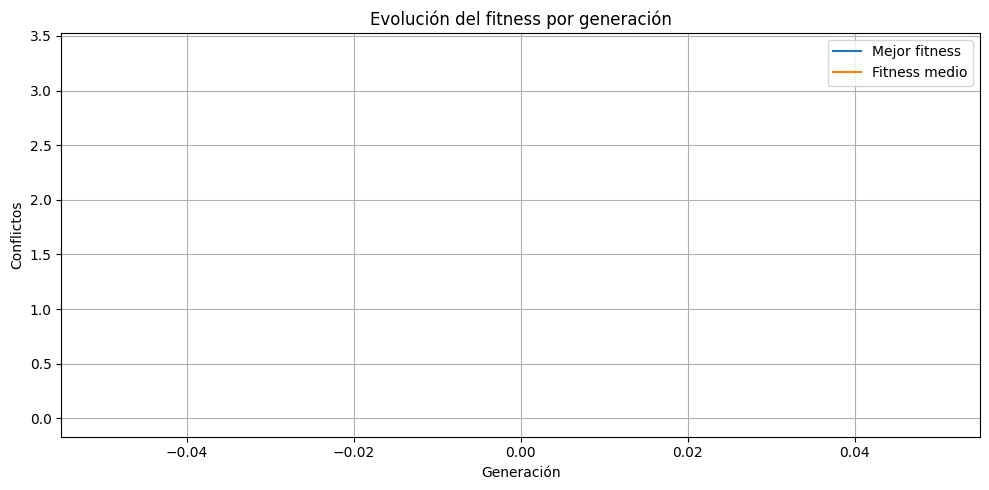

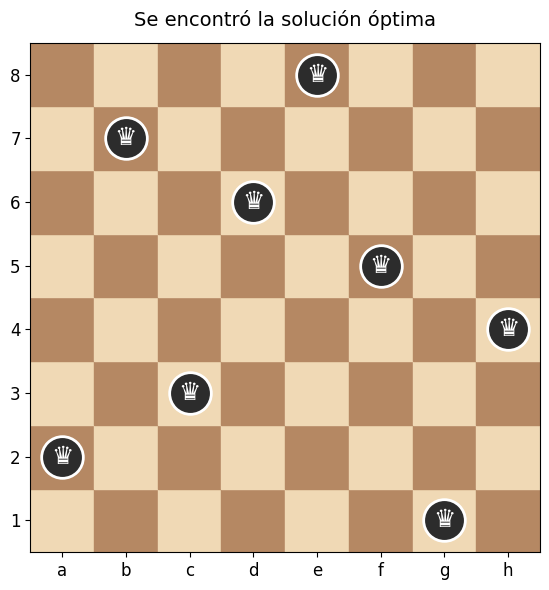

In [8]:
#Para probar la ejecución del código, se llama a la función
main()

Como se dijo antes, puede verse que, aún con los mismos parámetros, pueden darse diferentes soluciones si se ejecuta el código main varias veces. Igualmente, si se cambian los parámetros que están establecidos en el código de manera fija, como la probabilidad de cruce y mutación, se ven también diferentes resultados.